# EDA
The objective of this notebook is to explore the data contained in the file *labevents.csv* from MIMIC-IV. According to the MIMIC-IV documentation: "The labevents table stores the results of all laboratory measurements made for a single patient. These include hematology measurements, blood gases, chemistry panels, and less common tests such as genetic assays." Given our interest in studying kidney disease, five laboratory measurements are of particular interest. These are: ALT (itemid = 50861), Albumin (50862), ALP (50863), Bilirubin (50883), and Serum Creatinine (50912). With that in mind, the first step in our analysis is eliminating other laboratory measurements from *labevents.csv*. This was done using Excel, and the result was saved as *eda_data.csv*. In what follows, we try to understand this data, look for patterns, and uncover insights. 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [48]:
labs_df = pd.read_csv('../Data/eda_data.csv')
labs_df.head()

,labevent_id,subject_id,specimen_id,itemid,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag
0,11,10000032,83925500,50861,3/23/2180 11:51,3/23/2180 16:40,102,102.0,IU/L,0.0,40.0,abnormal
1,12,10000032,83925500,50862,3/23/2180 11:51,3/23/2180 16:40,3.3,3.3,g/dL,3.5,5.2,abnormal
2,13,10000032,83925500,50863,3/23/2180 11:51,3/23/2180 16:40,109,109.0,IU/L,35.0,105.0,abnormal
3,26,10000032,83925500,50912,3/23/2180 11:51,3/23/2180 16:40,0.4,0.4,mg/dL,0.4,1.1,NaN
4,96,10000032,95700408,50861,5/6/2180 22:25,5/6/2180 23:16,100,100.0,IU/L,0.0,40.0,abnormal


We begin by splitting the data into a train and test set. Following the best practices, the test set will not be touched until close to the end of the project. To perform the split, $20\%$ of the data is allocated to the test set. Also, a random state is set so that the same split will be obtained if the cell is rerun. 

In [49]:
from sklearn.model_selection import train_test_split
labs_df_train, labs_df_test = train_test_split(labs_df, 
                                              test_size = 0.2,
                                              random_state = 401)

One reasonable question to ask is: How many laboratory measurements are contained in this dataset? Each row of the pandas dataframe corresponds to a laboratory measurement, so this question can be answered by determining the number of rows in the dataframe. This is done in the next cell.

In [50]:
labs_df_train.shape[0]

46199

As indicated by the output above, there are $46,199$ laboratory measurements in the dataset. However, this does not necessarily provide much information about how many patients are in the dataset. Nor does it give us any sense of the typical number of laboratory measurements that pertain to a given patient. The next couple of cells address these questions. 


In [51]:
subject_ids = list(set(labs_df_train['subject_id']))
print('There are', len(subject_ids), 'distinct patients in the dataset.')

There are 1997 distinct patients in the dataset.


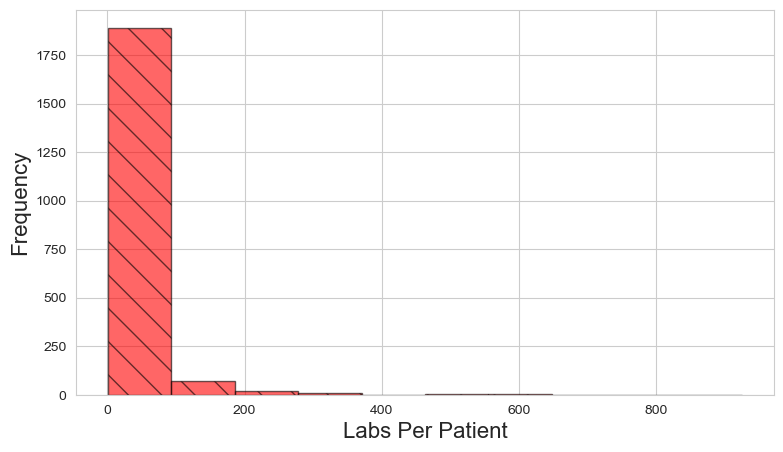

[  1.   93.4 185.8 278.2 370.6 463.  555.4 647.8 740.2 832.6 925. ]


In [106]:
patient_freq = [labs_df_train.loc[labs_df_train['subject_id'] == patient].shape[0] for patient in subject_ids]
plt.figure(figsize = (9, 5))
n, bins, patches = plt.hist(patient_freq,
        color = 'red',
        alpha = 0.6,
        hatch = '\\',
        edgecolor = 'black')
plt.ylabel('Frequency', fontsize = 16)
plt.xlabel('Labs Per Patient', fontsize = 16)
plt.show()
print(bins)

There are a few points worth mentioning about the results obtained above. First, there are $1,997$ patients in this dataset. Second, based on the histogram, the vast majority of these patients have somewhere between one and ninety-four laboratory measurements. However, it is also apparent that there are some outliers with a very large number of laboratory measurements (e.g., >= 400). To investigate this further, we compute a few sample statistics. 

In [71]:
mean_labs = np.mean(patient_freq)
std_labs = np.std(patient_freq)
percentiles = np.percentile(patient_freq, [25, 50, 75])
print('The average number of labs per patient is', np.round(mean_labs, 2))
print('The standard deviation of labs per patient is', np.round(std_labs, 2))
print('Twenty-five percent of the patients have less than or equal to', percentiles[0], 'labs.')
print('Fifty percent of the patients have less than or equal to', percentiles[1], 'labs.')
print('Seventy-five percent of the patients have less than or equal to', percentiles[2], 'labs.')

The average number of labs per patient is 23.13
The standard deviation of labs per patient is 57.76
Twenty-five percent of the patients have less than or equal to 2.0 labs.
Fifty percent of the patients have less than or equal to 6.0 labs.
Seventy-five percent of the patients have less than or equal to 19.0 labs.


According to the statistics computed above, there are fewer than twenty laboratory measurements for most patients. In fact, more than half of the patients have fewer than ten laboratory measurements. 

Having examined the patients in this dataset, we now turn our attention to the laboratory measurements. There are several questions of interest.
1. How many measurements are there for each of the five labs?
2. For each of the five labs, what proportion of these measurements are abnormal?
3. Is there any relationship between the laboratory measurements?

These questions are considered in the cells that follow.

In [99]:
lab_ids = [50861, 50862, 50863, 50883, 50912]
alt_labs = labs_df_train.loc[labs_df_train['itemid'] == lab_ids[0]]
albumin_labs = labs_df_train.loc[labs_df_train['itemid'] == lab_ids[1]]
alp_labs = labs_df_train.loc[labs_df_train['itemid'] == lab_ids[2]]
bilirubin_labs = labs_df_train.loc[labs_df_train['itemid'] == lab_ids[3]]
creatinine_labs = labs_df_train.loc[labs_df_train['itemid'] == lab_ids[4]]

print('The number of ALT labs is:', alt_labs.shape[0])
print('The number of Albumin labs is:', albumin_labs.shape[0])
print('The number of ALP labs is:', alp_labs.shape[0])
print('The number of Bilirubin labs is:', bilirubin_labs.shape[0])
print('The number of Serum Creatinine labs is:', creatinine_labs.shape[0])

The number of ALT labs is: 9395
The number of Albumin labs is: 5257
The number of ALP labs is: 8226
The number of Bilirubin labs is: 463
The number of Serum Creatinine labs is: 22858


Notice that the number of ALT, Albumin, and ALP labs is comparable (i.e., all between $5,000$ and $10,000$). The number of Bilirubin labs is much lower, while the number of Serum Creatinine labs is much higher. This observation is important because it indicates that, in terms of the number of measurements, there is not a one-to-one correspondence between the five labs. 

Next we answer the question: What proportion of these measurements are abnormal? This can be answered using both visualizations and statistics. 

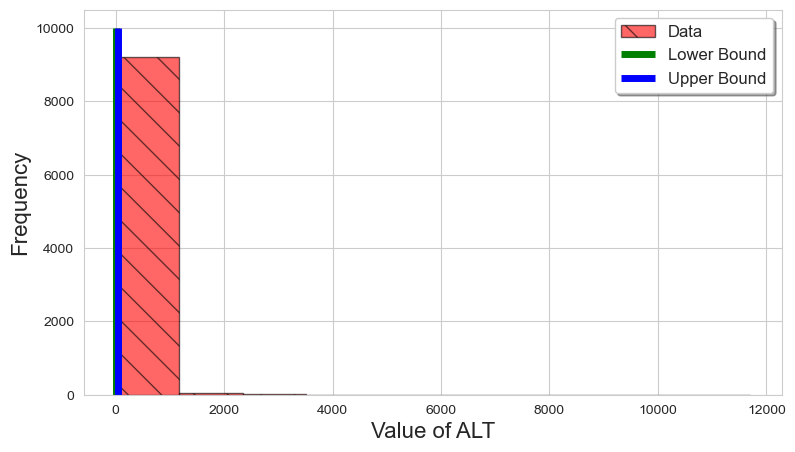

The proportion of the ALT labs that are abnormal is: 0.29


In [172]:
plt.figure(figsize = (9,5))
n, bins, patches = plt.hist(alt_labs['valuenum'],
                           color = 'red',
                           alpha = 0.6,
                           hatch = '\\',
                           edgecolor = 'black',
                           label = 'Data')
plt.vlines(x = 0, ymin = 0, ymax = 10000, color = 'green', linewidth = 5, label = 'Lower Bound')
plt.vlines(x = 40, ymin = 0, ymax = 10000, color = 'blue', linewidth = 5, label = 'Upper Bound')
plt.xlabel('Value of ALT', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right', fancybox = True, shadow = True)
plt.show()

alt_abnormal_prop = alt_labs['flag'].value_counts()['abnormal']/alt_labs.shape[0]
print('The proportion of the ALT labs that are abnormal is:', np.round(alt_abnormal_prop, 2))

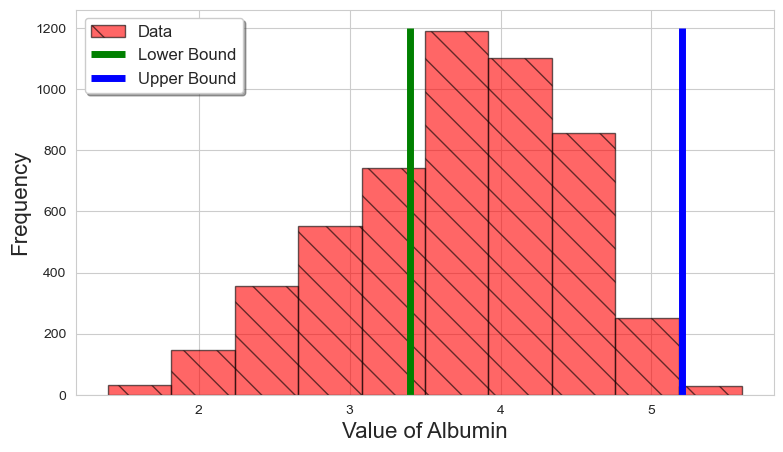

The proportion of Albumin labs that are abnormal is: 0.35


In [173]:
plt.figure(figsize = (9,5))
n, bins, patches = plt.hist(albumin_labs['valuenum'],
                           color = 'red',
                           alpha = 0.6,
                           hatch = '\\',
                           edgecolor = 'black',
                           label = 'Data')
plt.vlines(x = 3.4, ymin = 0, ymax = 1200, color = 'green', linewidth = 5, label = 'Lower Bound')
plt.vlines(x = 5.2, ymin = 0, ymax = 1200, color = 'blue', linewidth = 5, label = 'Upper Bound')
plt.xlabel('Value of Albumin', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper left', fancybox = True, shadow = True)
plt.show()

albumin_abnormal_prop = albumin_labs['flag'].value_counts()['abnormal']/albumin_labs.shape[0]
print('The proportion of Albumin labs that are abnormal is:', np.round(albumin_abnormal_prop, 2))

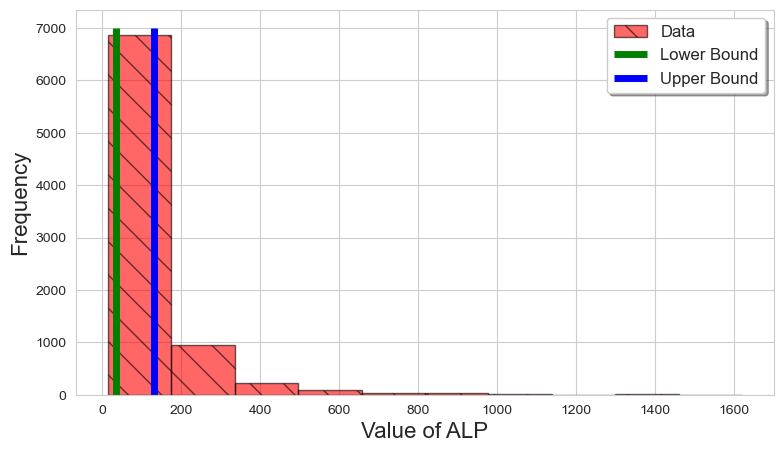

The proportion of ALP labs that are abnormal is: 0.34


In [174]:
plt.figure(figsize = (9,5))
n, bins, patches = plt.hist(alp_labs['valuenum'],
                           color = 'red',
                           alpha = 0.6,
                           hatch = '\\',
                           edgecolor = 'black',
                           label = 'Data')
plt.vlines(x = 35, ymin = 0, ymax = 7000, color = 'green', linewidth = 5, label = 'Lower Bound')
plt.vlines(x = 130, ymin = 0, ymax = 7000, color = 'blue', linewidth = 5, label = 'Upper Bound')
plt.xlabel('Value of ALP', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right', fancybox = True, shadow = True)
plt.show()

alp_abnormal_prop = alp_labs['flag'].value_counts()['abnormal']/alp_labs.shape[0]
print('The proportion of ALP labs that are abnormal is:', np.round(alp_abnormal_prop, 2))

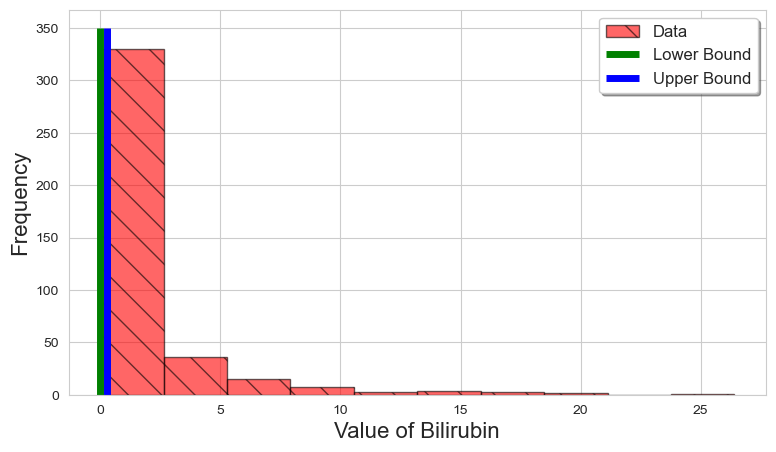

The proportion of Bilirubin labs that are abnormal is: 0.48


In [176]:
plt.figure(figsize = (9,5))
n, bins, patches = plt.hist(bilirubin_labs['valuenum'],
                           color = 'red',
                           alpha = 0.6,
                           hatch = '\\',
                           edgecolor = 'black',
                           label = 'Data')
plt.vlines(x = 0, ymin = 0, ymax = 350, color = 'green', linewidth = 5, label = 'Lower Bound')
plt.vlines(x = 0.3, ymin = 0, ymax = 350, color = 'blue', linewidth = 5, label = 'Upper Bound')
plt.xlabel('Value of Bilirubin', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right', fancybox = True, shadow = True)
plt.show()

bilirubin_abnormal_prop = bilirubin_labs['flag'].value_counts()['abnormal']/bilirubin_labs.shape[0]
print('The proportion of Bilirubin labs that are abnormal is:', np.round(bilirubin_abnormal_prop, 2))

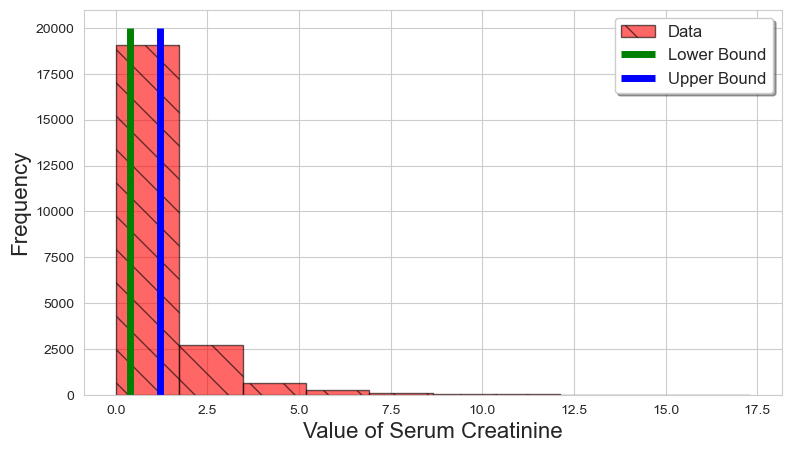

The proportion of Serum Creatinine labs that are abnormal is: 0.33


In [178]:
plt.figure(figsize = (9,5))
n, bins, patches = plt.hist(creatinine_labs['valuenum'],
                           color = 'red',
                           alpha = 0.6,
                           hatch = '\\',
                           edgecolor = 'black',
                           label = 'Data')
plt.vlines(x = 0.4, ymin = 0, ymax = 20000, color = 'green', linewidth = 5, label = 'Lower Bound')
plt.vlines(x = 1.2, ymin = 0, ymax = 20000, color = 'blue', linewidth = 5, label = 'Upper Bound')
plt.xlabel('Value of Serum Creatinine', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right', fancybox = True, shadow = True)
plt.show()

creatinine_abnormal_prop = creatinine_labs['flag'].value_counts()['abnormal']/creatinine_labs.shape[0]
print('The proportion of Serum Creatinine labs that are abnormal is:', np.round(creatinine_abnormal_prop, 2))

Note that the lower and upper bound in the histograms shown above come from the reference range interval given in the dataset. In cases where more than one lower (upper) bound is given in the dataset, the smallest (largest) value was used in the histogram. For each of the five lab measurements, the results obtained above indicate that a significant proportion of the measurements fall into the abnormal range. From the histograms, one can infer whether these measurements are abnormally low or high. 

Recall that our final question was whether there is any relationship between the different laboratory measurements. In order for the measurements to be comparable, they must come from the same patient. Therefore, analyzing any such potential relationship is not a straightforward task. Since we expect that low Albumin is a precursor of chronic kidney disease (CKD) diagnosis (i.e., Serum Creatinine becomes abnormally high and stays high), the remainder of this notebook focuses on those two labs. 

The number of patients with both Albumin and Serum Creatinine labs is: 1008


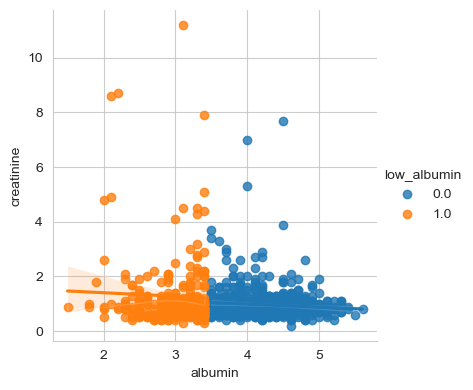

In [224]:
albumin_patients = set(albumin_labs['subject_id'])
creatinine_patients = set(creatinine_labs['subject_id'])
patient_list = list(albumin_patients.intersection(creatinine_patients))
lab_comparison_data = pd.DataFrame(columns = ['albumin', 'creatinine'])
for j, patient in enumerate(patient_list):
    albumin_vals = albumin_labs.loc[albumin_labs['subject_id'] == patient]
    creatinine_vals = creatinine_labs.loc[creatinine_labs['subject_id'] == patient]
    lab_comparison_data.loc[j] = [albumin_vals.loc[albumin_vals['charttime'] == albumin_vals['charttime'].min(), 'valuenum'].iloc[0],
                                 creatinine_vals.loc[creatinine_vals['charttime'] == creatinine_vals['charttime'].max(), 'valuenum'].iloc[0]]

lab_comparison_data['low_albumin'] = 1.0*(lab_comparison_data['albumin'] <= 3.4)
sns.lmplot(data = lab_comparison_data,
          x = 'albumin',
          y = 'creatinine',
          hue = 'low_albumin',
          height = 4)
print('The number of patients with both Albumin and Serum Creatinine labs is:', len(patient_list))

In the plot shown above, orange circles correspond to patients with low Albumin. The blue circles correspond to patients with normal (or high) albumin. With that in mind, there does not appear to be strong evidence that low Albumin is associated with high Serum Creatinine. However, this may be an artifact of how the data was selected. Namely, the Albumin measurement that was used is the first one available, while Serum Creatinine measurement is the last one available. The motivation behind this decision was the hypothesis that low Albumin is a precursor to high sustained levels of Serum Creatinine. That said, further consideration should be given to whether this selection method is appropriate. 

Finally, notice that requiring that the patient has measurements of both Albumin and Serum Creatinine reduced the amount of data that is available for analysis. While the original dataset had $1,997$ patients, only $1,008$ of those patients satisfied the previous criteria. 

In [10]:
import json 
with open('../Data/kidney_disease_patients.json', 'r') as file:
    patients_dict = json.load(file)
print(patients_dict['10002131'])

[[1, 2, 3, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 1, 2, 3, 4, 5, 6, 7], ['78650', '2948', '4263', 'I82412', 'I5033', 'E873', 'E46', 'I482', 'G309', 'I82432', 'F0280', 'I10', 'E876', 'M810', 'Z66', 'Z515', 'Z993', 'H9192', 'H409', 'M25551', 'K5900', 'Z6827', 'Z85828', '5849', '00863', '27651', '5641', '2948', '37230', 'V4986'], [9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9]]


In [11]:
print(patients_dict['10002131'][0])

[1, 2, 3, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 1, 2, 3, 4, 5, 6, 7]


In [12]:
print(patients_dict['10002131'][1])

['78650', '2948', '4263', 'I82412', 'I5033', 'E873', 'E46', 'I482', 'G309', 'I82432', 'F0280', 'I10', 'E876', 'M810', 'Z66', 'Z515', 'Z993', 'H9192', 'H409', 'M25551', 'K5900', 'Z6827', 'Z85828', '5849', '00863', '27651', '5641', '2948', '37230', 'V4986']


In [13]:
print(patients_dict['10002131'][2])

[9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9]
